선택된 Feature:
['flavanoids', 'od280/od315_of_diluted_wines', 'proline']
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7c4a02aca0980a4eff.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


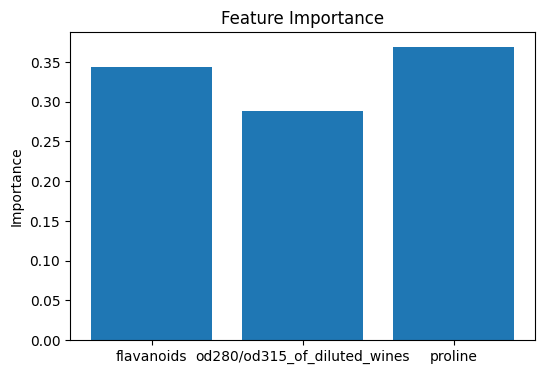

In [4]:
# =========================================================
# Wine Prediction AI Service
# =========================================================

# pip install scikit-learn gradio pandas matplotlib

import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# =========================================================
# 1. 데이터 로드
# =========================================================
wine = load_wine()

df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

df["target"] = wine.target

X = df[wine.feature_names]
y = df["target"]

# =========================================================
# 2. 데이터 분리
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================================
# 3. 머신러닝 Pipeline
# =========================================================
pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),

    (
        "selector",
        SelectKBest(
            score_func=f_classif,
            k=3
        )
    ),

    (
        "model",
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )
    )
])

# =========================================================
# 4. 모델 학습
# =========================================================
pipeline.fit(X_train, y_train)

# =========================================================
# 5. 모델 평가
# =========================================================
pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, pred)

report = classification_report(
    y_test,
    pred,
    target_names=wine.target_names
)

# =========================================================
# 6. 선택된 Feature 확인
# =========================================================
selector = pipeline.named_steps["selector"]

selected_mask = selector.get_support()

selected_features = X.columns[selected_mask]

print("선택된 Feature:")
print(selected_features.tolist())

# =========================================================
# 7. Feature Importance 시각화
# =========================================================
model = pipeline.named_steps["model"]

importance = model.feature_importances_

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(selected_features, importance)

ax.set_title("Feature Importance")
ax.set_ylabel("Importance")

# =========================================================
# 8. 예측 기록 저장
# =========================================================
history = []

# =========================================================
# 9. 예측 함수
# =========================================================
def predict_wine(
    alcohol,
    malic_acid,
    ash,
    alcalinity_of_ash,
    magnesium,
    total_phenols,
    flavanoids,
    nonflavanoid_phenols,
    proanthocyanins,
    color_intensity,
    hue,
    od280_od315_of_diluted_wines,
    proline
):

    input_df = pd.DataFrame([[
        alcohol,
        malic_acid,
        ash,
        alcalinity_of_ash,
        magnesium,
        total_phenols,
        flavanoids,
        nonflavanoid_phenols,
        proanthocyanins,
        color_intensity,
        hue,
        od280_od315_of_diluted_wines,
        proline
    ]], columns=wine.feature_names)

    # 예측
    prediction = pipeline.predict(input_df)[0]

    # 확률
    probability = pipeline.predict_proba(input_df)[0]

    # 클래스명
    class_name = wine.target_names[prediction]

    result = (
        f"🍷 예측 결과: {class_name}\n\n"
        f"📊 예측 확률\n"
        f"----------------------------------\n"
        f"class_0 : {probability[0]*100:.2f}%\n"
        f"class_1 : {probability[1]*100:.2f}%\n"
        f"class_2 : {probability[2]*100:.2f}%"
    )

    # 기록 저장
    history.append([
        alcohol,
        color_intensity,
        class_name
    ])

    history_df = pd.DataFrame(
        history,
        columns=[
            "alcohol",
            "color_intensity",
            "prediction"
        ]
    )

    return result, history_df

# =========================================================
# 10. Gradio UI
# =========================================================
with gr.Blocks() as app:

    gr.Markdown(
        """
# 🍷 Wine Prediction AI Service

머신러닝 기반 와인 품질 예측 시스템

### 적용 기술
- StandardScaler
- Feature Selection
- RandomForestClassifier
- Gradio Web UI
"""
    )

    # =====================================================
    # Prediction Tab
    # =====================================================
    with gr.Tab("Prediction"):

        with gr.Row():

            with gr.Column():

                alcohol = gr.Number(label="alcohol")
                malic_acid = gr.Number(label="malic_acid")
                ash = gr.Number(label="ash")
                alcalinity_of_ash = gr.Number(label="alcalinity_of_ash")
                magnesium = gr.Number(label="magnesium")
                total_phenols = gr.Number(label="total_phenols")
                flavanoids = gr.Number(label="flavanoids")

            with gr.Column():

                nonflavanoid_phenols = gr.Number(
                    label="nonflavanoid_phenols"
                )

                proanthocyanins = gr.Number(
                    label="proanthocyanins"
                )

                color_intensity = gr.Number(
                    label="color_intensity"
                )

                hue = gr.Number(label="hue")

                od280_od315_of_diluted_wines = gr.Number(
                    label="od280/od315_of_diluted_wines"
                )

                proline = gr.Number(label="proline")

        predict_btn = gr.Button(
            "Predict",
            variant="primary"
        )

        output_text = gr.Textbox(
            label="Prediction Result",
            lines=8
        )

        history_table = gr.Dataframe(
            label="Prediction History"
        )

        predict_btn.click(
            fn=predict_wine,
            inputs=[
                alcohol,
                malic_acid,
                ash,
                alcalinity_of_ash,
                magnesium,
                total_phenols,
                flavanoids,
                nonflavanoid_phenols,
                proanthocyanins,
                color_intensity,
                hue,
                od280_od315_of_diluted_wines,
                proline
            ],
            outputs=[
                output_text,
                history_table
            ]
        )

    # =====================================================
    # Model Info Tab
    # =====================================================
    with gr.Tab("Model Info"):

        model_info = f"""
Accuracy : {accuracy:.4f}

Selected Features:
{selected_features.tolist()}

Classification Report:

{report}
"""

        gr.Textbox(
            value=model_info,
            label="Model Performance",
            lines=20
        )

        gr.Plot(fig)

# =========================================================
# 11. 서버 실행
# =========================================================
gr.close_all()

app.launch(
    share=True
)

In [2]:
import gradio as gr

gr.close_all()